In [ ]:
# Polynomial Regression

# Полиномиальная регрессия (Polynomial Regression)

## Идея

Что если данные не похожи на прямую линию? Оказывается, линейную модель можно применить и к **нелинейным** данным. Простой способ: добавить **степени** каждого признака как новые признаки, а затем обучить линейную модель уже на этом расширенном наборе. Это называется **полиномиальная регрессия**.

## Пример данных

Сгенерируем нелинейные данные по формуле квадратного уравнения `y = ax² + bx + c` плюс шум:

```python
rng = np.random.default_rng(seed=42)
m = 200
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1))
```

Как видно на графике выше (изображение 1) — прямая линия тут никак не подойдёт, данные явно изогнутые (парабола + шум).

## Решение — PolynomialFeatures

Используем `PolynomialFeatures` из sklearn, чтобы добавить **квадрат** каждого признака как новый признак:

```python
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

X[0]
# array([1.64373629])

X_poly[0]
# array([1.64373629, 2.701869])
```

Теперь `X_poly` содержит **исходный признак** X плюс его **квадрат** (`1.64² ≈ 2.70`).

## Обучаем обычную линейную регрессию на расширенных данных

```python
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

lin_reg.intercept_, lin_reg.coef_
# (array([2.00540719]), array([[1.11022126, 0.50526985]]))
```

Результат (см. график выше, изображение 2 — красная кривая): модель предсказывает `ŷ = 0.56x₁² + 0.93x₁ + 1.78`, при том что настоящая формула была `y = 0.5x₁² + 1.0x₁ + 2.0 + шум`. Довольно близко!

## Полиномиальная регрессия для нескольких признаков

Когда признаков несколько, полиномиальная регрессия умеет находить **взаимосвязи между признаками** — то, что обычная линейная регрессия делать не может.

Это происходит потому, что `PolynomialFeatures` добавляет **все комбинации признаков** вплоть до заданной степени. Например, если есть 2 признака `a` и `b`, при `degree=3` будут добавлены не только `a²`, `a³`, `b²`, `b³`, но и комбинации `ab`, `a²b`, `ab²`.

## ⚠️ ПРЕДУПРЕЖДЕНИЕ

`PolynomialFeatures(degree=d)` превращает массив из `n` признаков в массив из **`(n + d)! / (d! × n!)`** признаков (`!` — факториал, `n! = 1 × 2 × 3 × ... × n`).

**Осторожно**: число признаков растёт комбинаторно (взрывным образом) при увеличении числа исходных признаков или степени `degree`!

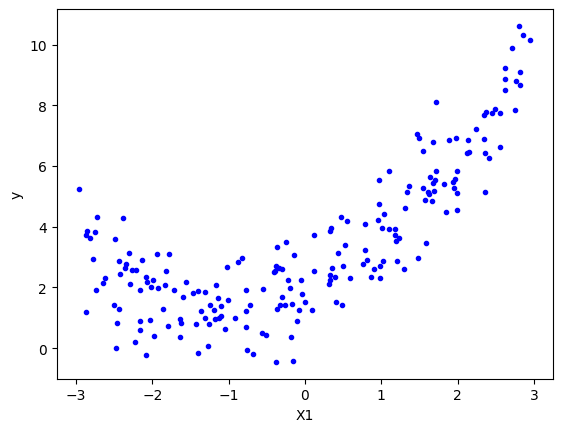

X: [[ 1.64373629]
 [-0.36672936]
 [ 2.15158752]] 
 y: [[5.63799758]
 [1.30591073]
 [6.46113008]]


In [27]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1))

plt.plot(X,y, "b.")
plt.xlabel("X1")
plt.ylabel("y")
plt.show()

print("X:",X[0:3],"\n","y:",y[0:3])
# На графике явно видно что это нелинейное, так как есть изгиб (чаша парабола, а не прямая)

In [28]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])
# Добавляем еще один столбец (квадрат исходного признака)
# 2 признака — исходный x, и x²=1.64²=2.70

# При обычной формуле линейной регрессии y = θ₀ + θ₁x (только прямая линия)
# Если два признака y = θ₀ + θ₁x + θ₂x² (парабола) 
# (но для компа это все еще линейная регрессия)
# потому что θ₀, θ₁, θ₂ всё ещё просто умножаются на признаки и складываются 
# (модель не знает и ей не важно, что один из признаков — 
# это квадрат другого, она просто видит "два столбца чисел")


[1.64373629]
[1.64373629 2.701869  ]


In [12]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print("θ0 (bias) ", lin_reg.intercept_, "\nэто θ1 (вес x) и θ2 (вес x²)", lin_reg.coef_)
# итоговая формула y = 2.01 + 1.11*x + 0.51*x²


θ0 (bias)  [2.00540719] 
это θ1 (вес x) и θ2 (вес x²) [[1.11022126 0.50526985]]


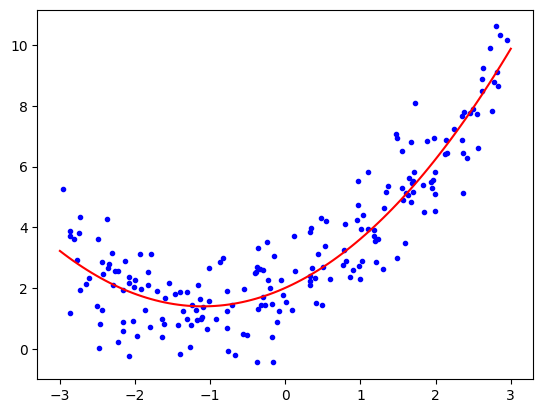

In [30]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)   # 100 точек от -3 до 3
# poly_features уже с добавленной фичей
X_new_poly = poly_features.transform(X_new)         # добавляем x^2 к каждой из них
y_new = lin_reg.predict(X_new_poly)                 # получаем предсказания

plt.plot(X, y, "b.")               # синие точки — исходные данные
plt.plot(X_new, y_new, "r-")       # красная линия — предсказания модели